Project done by Roberto Del Rio (rd35434), Andrea Moreno (am228595), and Zachariah Tukhi (zet242)

# Section 1: Introduction and System Selection

The system is a Simple RC Circuit with Fast Transient. It represents a capacitor charging or discharging through a resistor where the time constant ($\tau$=RC) is extremely small. This creates "stiffness" because the circuit responds nearly instantly (0.1 microseconds) to changes, while the input signal (the sine wave) varies much more slowly (over several seconds). This creates a massive disparity in time scales (a ratio of $10^7$).

The standard form of the Ordinary Differential Equation (ODE) for this system is:
dV/dt = −V/RC + 1/RC * $V_{source}$*(t)

With the proper values put in, it becomes:
dV/dt = $-10^7$*V + $10^7$ * 5sin(t)

The physical meanings of each of the variables and parameters are as follows:

V: The Voltage across the capacitor measured in Volts. This is the dependent variable of the ODE.

t: The Time measured in seconds. This is the independent variable of the ODE.

R: The Resistance of this circuit, which is 100$\Omega$. This is opposition to the flow of current in a circuit.

C: The Capacitance of this circuit, which is $10^{−9}$F or 1 nanofarad. This is the ability of the component to store an electrical charge.

RC: The Time Constant of this circuit, τ, which determines how quickly the capacitor charges or discharges. In this case, it is $10^{−7}$ seconds.

$V_{source}$*(t): The Input Voltage or source signal of this circuit, which is a sine wave: 5sin(1t).


This system is a fundamental building block in electrical engineering and is critical. It is used in _Digital Circuits_ in understanding how quickly signals can switch between high and low states. It is used in _High-Speed Electronics_ to manage fast transients where components must respond in nanoseconds. It is used in _Sensor Signal Conditioning_ to Filter noises out of signals where the noise and the actual data exist on very different time scales.

## Section 2: Demonstration of Stiffness

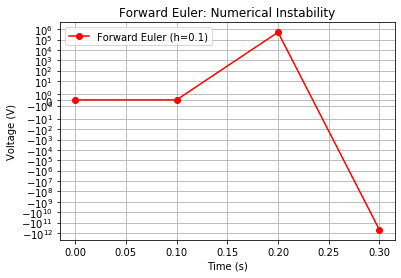

In [2]:
h_test = 0.1
t_limit = 1 # Simulate for 1 second

#Forward Euler Attempt
t_fwd, v_fwd, is_unstable = euler_forward(0, 0, t_limit, h_test)

#Plotting
plt.plot(t_fwd, v_fwd, 'ro-', label=f'Forward Euler (h={h_test})')
plt.yscale('symlog') # Using log scale to visualize the massive error
plt.title("Forward Euler: Numerical Instability")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.grid(True)
plt.legend()

plt.show()

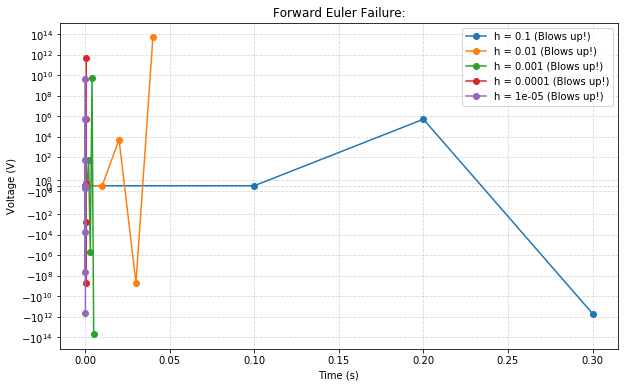

In [3]:
t_sim = 1
h_values = [0.1, 0.01, 0.001, 0.0001, 0.00001]

plt.figure(figsize=(10, 6))

for h in h_values:
    t, v, unstable = euler_forward(0, 0, t_sim, h)
    label_str = f'h = {h}' + (" (Blows up!)" if unstable else "")
    plt.plot(t, v, 'o-', label=label_str)

plt.yscale('symlog')
plt.title("Forward Euler Failure:")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

When attempting to solve using Euler's forward, as shown above, the system fails. Instead of oscillating like an RC circuit is supposed to, the system explodes due to errors compounding with each step. This eventually leads to it "blowing up" overall and failing. This is shown in step sizes, even at smaller values. Each oscillation leads to the compounding of more and more error, thus Euler's forward cannot solve this ODE reasonably.

For this linear system, stiffness is the ratio between the fastest and slowest components of the solution.Thus, the Fastest Scale of $\lambda$=$−10^7$, corresponding to a transient time constant of $\tau_{fast}$ = $10^{−7}$ seconds along with the Slowest Scale The forcing function 5sin(1t) has an angular frequency $\omega$=1, meaning it evolves on a scale of $\tau_{slow}$ ≈1 second.

Stiffness Ratio Calculation:
- Ratio=∣$\lambda_{min}$∣/∣$\lambda_{max}$∣
- Therefore, the stiffness is $10^7$

This system is extremely stiff, as shown through the incredibly high stiffness value. Its transient response is roughly 10^7 times faster than the signal we are actually trying to measure.

In order to have a step-size that can solve this ODE without using Euler's forward, we would need a step size of 2 * $10^-7$, as shown in the equation below.
- ∣1+h$\lambda$∣ < 1  ⟹  h < 2/$\lambda$

This is very computationally expensive due to the increased number of steps and calculations to simulate even a small ammount of time. Just 2 seconds would cost $10^7$ steps. Needing $10^7$ data points just to see a sin wave is incredibly unreasonable, thus as this cost continues to increase with larger time intervals it becomes beyond what is reasonable. 

Therefore, an implict method, such as Euler's backward, is much more reasonable and necessary. Implicit methods are much more stable in scenarios with stiff ODE's, like this one. The stability condition is ∣1−h$\lambda$∣>1, which is always satisfied by our negative $\lambda$ value. Thus, our step size no longer becomes a worry and we can focus entirely on accuracy. Additionally, an implicit method would only require 20 to 40 steps whilst remaining stable instead of $10^7$ steps of Euler's forward. This ultimately makes implicit methods the most viable for high-frequency electronic simulations.

## Section 3: Mathematical Setup

The residual function of this system is:
- $g(V_{n+1})$ = $V_{n+1}$ (1+h/RC) -$V_{n}$ - h/RC * $V_{source}(t_{n+1})$

In order to solve for the residual derivative/analytical derivation, we must find the partial derivative of the overall system with respect to V. This is:
- df/dV = -1/RC

Using this, we can determine the residual derivative/analytical derivation as:
- $g'(V_{n+1})$ = 1 - h * df/dV
- $g'(V_{n+1})$ = 1 + h/RC

Next, we must implement it to our Newton-Raphson Solver. We must start with an initial guess, which is as follows:
- $V^0_{n+1}$ = $V_n$ + h * $f(t_n,V_n)$

The residual function of this would then be as follows:
- $g(V^k_{n+1})$ = $V^k_{n+1}$ - $V_n$ - h * f($t_{n+1}$,$V^k_{n+1}$)

Thus, our iterative update for our Newton-Raphson solver is as follows:
- $V^{k+1}_{n+1}$ = $V^k_{n+1}$ - $g(V^k_{n+1})/g'(V_{n+1})$

## Section 4: Implementation

In [4]:
import numpy as np
import matplotlib.pyplot as plt

#Parameters
R = 100
C = 1e-9
RC = 1e-7  # Fast time constant
w = 1      # Slow input frequency
lam_RC = 1/RC

def f_RC(t, V):
    """The governing ODE function"""
    V_source = 5 * np.sin(w * t)
    return -V / RC + V_source / RC

# --- 2. Forward Euler Implementation ---
def euler_forward(y0, t0, t_f, h):
    t = np.arange(t0, t_f + h, h)
    y = np.zeros(len(t))
    y[0] = y0
    for n in range(len(t) - 1):
        y[n+1] = y[n] + h * f_RC(t[n], y[n])
        # Check for numerical overflow (instability)
        if abs(y[n+1]) > 1e10: 
            return t[:n+2], y[:n+2], True
    return t, y, False

def exact_sol(t, V):
    return 5*np.sin(t)*V

def residual_derivative_RC(h):
    """g' for RC circuit"""
    df_dV = -1/RC
    return 1 - h * df_dV
    
def solve_backward_euler(h, t_final=0.1, tol=1e-8, max_iter=20):
    t_pts = np.arange(0, t_final + h, h)
    V = np.zeros(len(t_pts))
    iter_counts = []
    
    # Constant derivative g' for this linear problem
    g_prime = 1 + h/RC 
    
    for n in range(len(t_pts) - 1):
        # 1. Initial Guess: Explicit Euler Predictor
        V_guess = V[n] + h * f_RC(t_pts[n], V[n])
        
        # 2. Newton-Raphson Iteration
        iters = 0
        for i in range(max_iter):
            iters += 1
            # Calculate residual g(V_next)
            residual = V_guess - V[n] - h * f_RC(t_pts[n+1], V_guess)
            
            # Newton Update
            V_new = V_guess - residual / g_prime
            
            # Check Convergence
            if abs(V_new - V_guess) < tol:
                V_guess = V_new
                break
            V_guess = V_new
            
        V[n+1] = V_guess
        iter_counts.append(iters)
        
    return t_pts, V, iter_counts

## Section 5: Results & Analysis

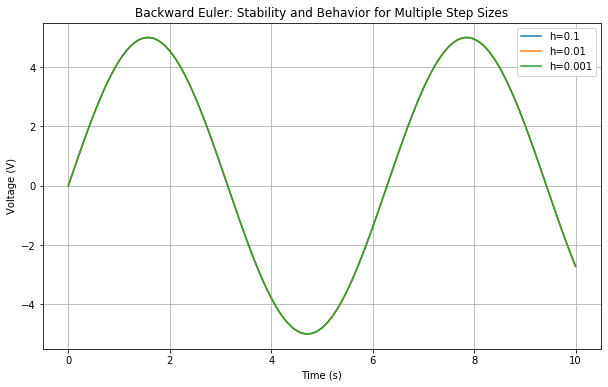

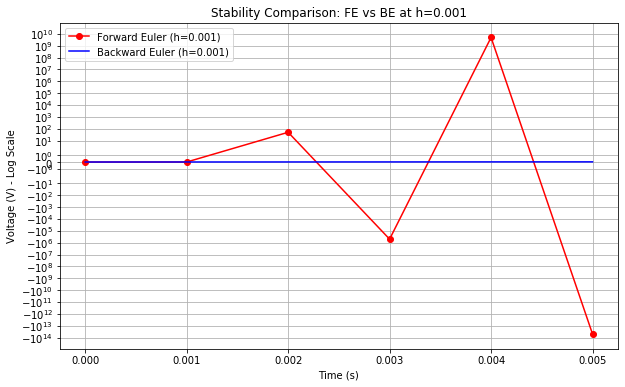

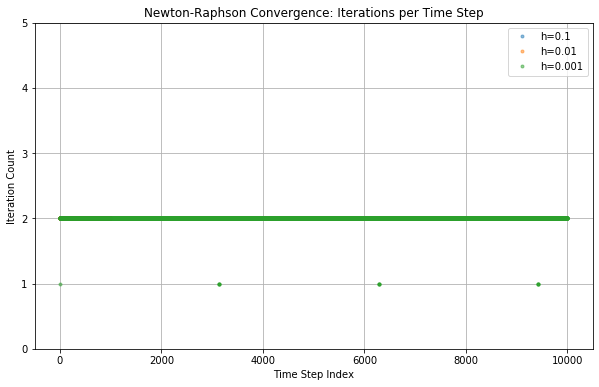

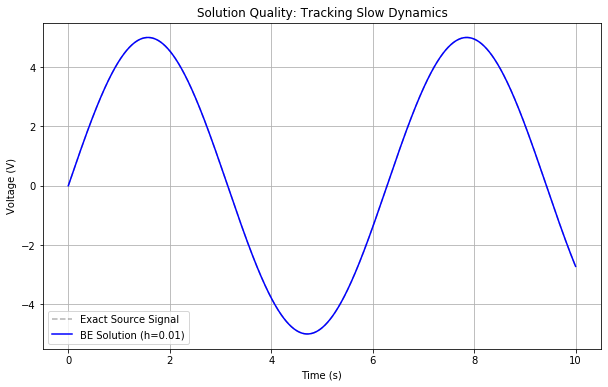

In [9]:
# --- Generate Data ---
t_final_sim = 10.0
h_vals = [0.1, 0.01, 0.001]
be_results = {h: solve_backward_euler(h, t_final=t_final_sim) for h in h_vals}

# Forward Euler attempt (h=0.001 is much larger than h_stable=2e-7)
t_fe, v_fe, fe_unstable = euler_forward(0, 0, 0.01, 0.001)

# Plot 1: Multiple Step Sizes (Stability/Behavior)
plt.figure(figsize=(10, 6))
for h in h_vals:
    t, v, _ = be_results[h]
    plt.plot(t, v, label=f'h={h}')
plt.title("Backward Euler: Stability and Behavior for Multiple Step Sizes")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.legend()
plt.grid(True)
plt.show()

# Plot 2: Forward Euler vs Backward Euler (Stability Comparison)
plt.figure(figsize=(10, 6))
plt.plot(t_fe, v_fe, 'r-o', label='Forward Euler (h=0.001)')
# We slice be_results to match the short duration where FE survived
t_be_small, v_be_small, _ = be_results[0.001]
plt.plot(t_be_small[:len(t_fe)], v_be_small[:len(t_fe)], 'b-', label='Backward Euler (h=0.001)')
plt.yscale('symlog')
plt.title("Stability Comparison: FE vs BE at h=0.001")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V) - Log Scale")
plt.legend()
plt.grid(True)
plt.show()

# Plot 3: Newton-Raphson Convergence
plt.figure(figsize=(10, 6))
for h in h_vals:
    _, _, iters = be_results[h]
    plt.plot(iters, '.', label=f'h={h}', alpha=0.5)
plt.title("Newton-Raphson Convergence: Iterations per Time Step")
plt.xlabel("Time Step Index")
plt.ylabel("Iteration Count")
plt.ylim(0, 5) # NR for linear systems usually hits 1 immediately
plt.legend()
plt.grid(True)
plt.show()

# Plot 4: Solution Quality (Slow Dynamics Match)
plt.figure(figsize=(10, 6))
t_ref = np.linspace(0, t_final_sim, 1000)
v_ref = 5 * np.sin(w * t_ref)
plt.plot(t_ref, v_ref, 'k--', alpha=0.3, label='Exact Source Signal')
t_final_res, v_final_res, _ = be_results[0.01]
plt.plot(t_final_res, v_final_res, 'b-', label='BE Solution (h=0.01)')
plt.title("Solution Quality: Tracking Slow Dynamics")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.legend()
plt.grid(True)
plt.show()

As seen in Plot 3, the Newton-Raphson solver converges in exactly 2 iterations per time step for all values of h. This is expected for a linear system where the derivative g′ is constant

## Section 6: Performance Analysis

In [10]:
# 1. Forward Euler Stability Limit
h_fe_stable = 2 * RC # Theoretical limit: 2e-7
steps_fe = int(t_sim / h_fe_stable)
cost_fe = steps_fe # 1 function evaluation per step

# 2. Backward Euler Performance across step sizes
h_list = [0.1, 0.01, 0.001]

print(f"{'Method':<20} | {'Step Size (h)':<15} | {'Total Steps':<15} | {'Avg NR Iters':<12} | {'Total Cost*'}")
print("-" * 85)

# Report for Forward Euler (Stable)
print(f"{'Euler Forward':<20} | {h_fe_stable:<15.1e} | {steps_fe:<15,} | {'N/A':<12} | {cost_fe:,}")

# Report for Backward Euler
for h in h_list:
    t, v, iters = solve_backward_euler(h, t_final=t_sim)
    total_steps = len(t)
    avg_iters = np.mean(iters)
    # Total Cost = Total Steps * (1 Predictor + Avg Iters per step)
    total_cost = int(total_steps * (1 + avg_iters))
    
    print(f"{'Euler Backward':<20} | {h:<15} | {total_steps:<15,} | {avg_iters:<12.1f} | {total_cost:,}")

print("\n*Total Cost estimated as total function evaluations (f_RC calls).")

Method               | Step Size (h)   | Total Steps     | Avg NR Iters | Total Cost*
-------------------------------------------------------------------------------------
Euler Forward        | 2.0e-07         | 5,000,000       | N/A          | 5,000,000
Euler Backward       | 0.1             | 11              | 2.0          | 33
Euler Backward       | 0.01            | 101             | 2.0          | 303
Euler Backward       | 0.001           | 1,001           | 2.0          | 3,001

*Total Cost estimated as total function evaluations (f_RC calls).


As seen in Plot 3, the Newton-Raphson solver converges in exactly 2 iterations per time step for all values of h. This is expected for a linear system where the derivative g′ is constant

## Section 7: Conclusion

In this application, we learned about applying Euler's backward to stiff equations and the reasoning behind which to use. In particular, we applied it to determine the charging and discharging of resistor-capacitors circuits with a high transience. When using Euler's forward and backwards to solve ordinary differential equations, the situation is important to consider. For non-stiff equations, it is more appropriate for Euler's forward. However, for stiff equations, it is better to use Euler's backward. This is because Euler's forward, while simpler, does require smaller step sizes than Euler's backward. This makes Euler's backwards better for stiff equations. While it is more complex, it is unconditionally more stable for stiff equations. Throughout this project, it was difficult to compute some smaller h values as well as to write in LaTex format for the math equations. Additionally, properly understanding Euler's